#  Below is Python code that runs an Integrate and Fire Model, Take some time to investigate the code and then complete the worksheet on Canvas titled "Worksheet 2, Integrate & Fire"

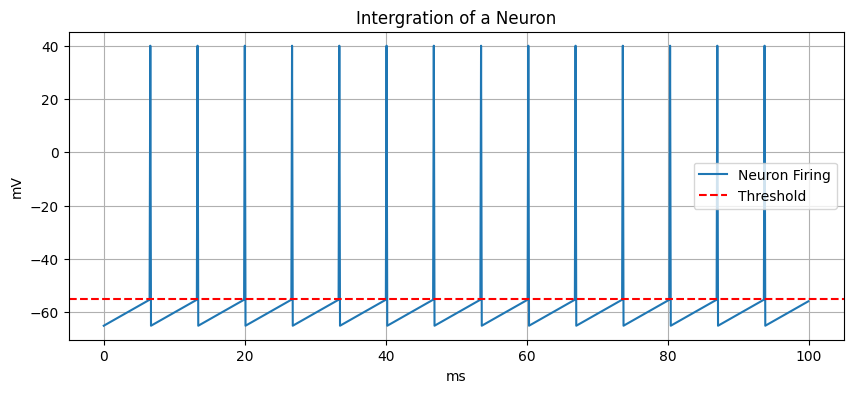

In [ ]:
# Jupyter: enable plot rendering inside the notebook (this allows us to actually show the output of the code visually)
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# --- Neuron Parameters (realistic, in mV and pA) ---
C = 200.0   #   current it equal to 200
V_th = -55.0 #is the voltage at threshold for a neuron
V_reset = -65.0 #V_reset is when the neuron is equilibrium
V_rest =  -65.0 #is when the neuron is at repolarized
I_ext = 300.0    #I is current for a neuron
dt = 0.1   #amount of time it takes for


T = 100          # total simulation time in ms
dt = 0.1         # time step in ms
time = np.arange(0, T, dt)  # time vector

# --- Initialize voltage and spike times ---
V = np.full_like(time, V_rest)  # set all values to resting voltage
spike_times = []

# --- Simulation Loop ---
for i in range(1, len(time)):
    dV = (I_ext / C) * dt       # ΔV = (I / C) * dt, in mV
    V[i] = V[i-1] + dV

    if V[i] >= V_th:
        V[i-1] = 40.0           # mark spike as +40 mV (for visualization)
        V[i] = V_reset
        spike_times.append(time[i])

# --- Plotting ---
plt.figure(figsize=(10, 4))
plt.plot(time, V, label='Neuron Firing')
plt.axhline(V_th, color='r', linestyle='--', label='Threshold')
plt.xlabel('ms') #what should the x be?
plt.ylabel('mV') #what should the y be?
plt.title('Intergration of a Neuron') #what is a good title?
plt.legend() #can you think of a legend?
plt.grid(True)
plt.show()



In [ ]:
def simulate_neuron(I_ext):
    V = np.full_like(time, V_rest)
    spike_times = []

    for i in range(1, len(time)):
        dV = (I_ext / C) * dt
        V[i] = V[i-1] + dV

        if V[i] >= V_th:
            V[i-1] = 40.0
            V[i] = V_reset
            spike_times.append(time[i])

    return spike_times


In [ ]:
n_neurons = 5
spike_trains = []

for neuron in range(1, n_neurons + 1):

    if neuron % 2 == 1:      # odd neurons excited
        I_ext = 350.0
    else:                   # even neurons inhibited
        I_ext = 150.0

    spikes = simulate_neuron(I_ext)
    spike_trains.append(spikes)


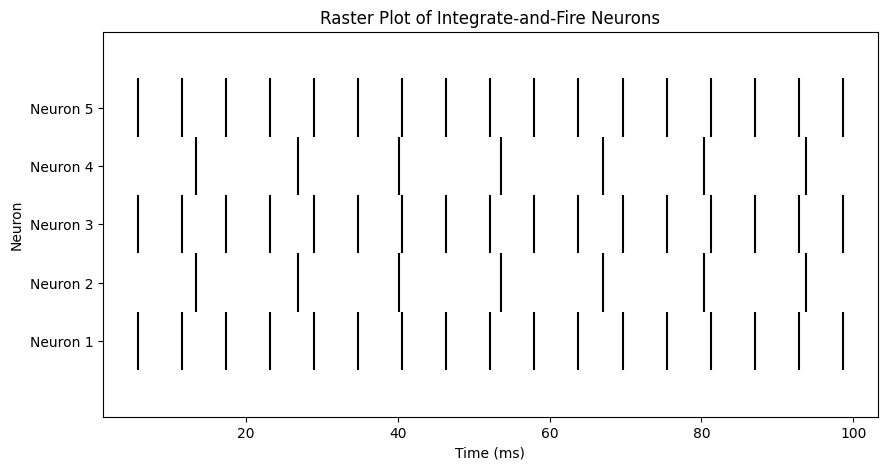

In [ ]:
plt.figure(figsize=(10, 5))
plt.eventplot(spike_trains, colors='black')

plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.yticks(range(n_neurons), [f'Neuron {i}' for i in range(1, n_neurons + 1)])
plt.title('Raster Plot of Integrate-and-Fire Neurons')

plt.show()


In [ ]:
input_currents = [150, 200, 250, 300, 350]  # pA
spike_trains = []

for I in input_currents:
    spikes = simulate_neuron(I)
    spike_trains.append(spikes)


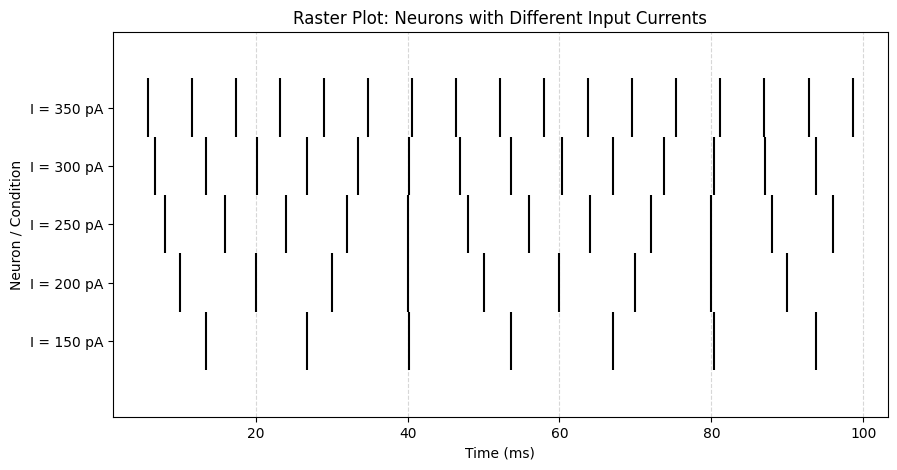

In [ ]:
plt.figure(figsize=(10, 5))

plt.eventplot(spike_trains, colors='black')

plt.xlabel('Time (ms)')
plt.ylabel('Neuron / Condition')
plt.yticks(
    range(len(input_currents)),
    [f'I = {I} pA' for I in input_currents]
)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.title('Raster Plot: Neurons with Different Input Currents')

plt.show()
